In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

In [6]:
cg=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc')
p1e4=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P10000T20.0seconds.nc')
p6e4=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc')

/tmp/ipykernel_1024003/3840148700.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  p1e4=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P10000T20.0seconds.nc')
/tmp/ipykernel_1024003/3840148700.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is

In [26]:
lonr=cg['lon_rho'].values
latr=cg['lat_rho'].values

In [27]:
u1=u2rho_3d(np.squeeze(cg['u'].values))
v1=v2rho_3d(np.squeeze(cg['v'].values))
dx=1/512*2*np.pi
dy=dx
ux=u2rho_3d(u1[:,:,1:]-u1[:,:,:-1])/dx
vx=u2rho_3d(v1[:,:,1:]-v1[:,:,:-1])/dx
uy=v2rho_3d(u1[:,1:,:]-u1[:,:-1,:])/dy
vy=v2rho_3d(v1[:,1:,:]-v1[:,:-1,:])/dy
vor=(vx-uy)/100

In [42]:
lon1e4=p1e4['lon'].values
lat1e4=p1e4['lat'].values
lon6e4=p6e4['lon'].values
lat6e4=p6e4['lat'].values

In [62]:
lon1e4.shape

(10000, 173)

# plt

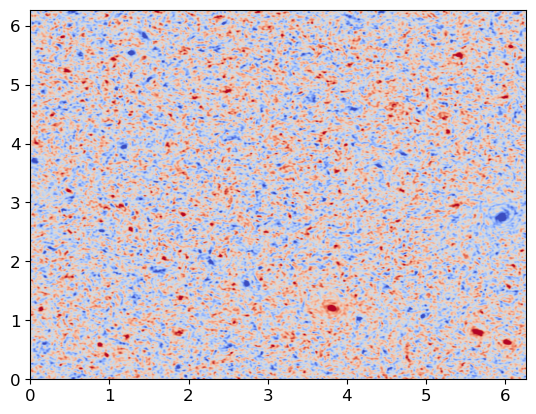

In [79]:
tindex=0
tindex2=41
tindexp=14
plt.pcolormesh(lonr,latr,vor[tindex,:,:],cmap='coolwarm',vmin=-4,vmax=4,shading='gouraud')

# coolwarm
# extend='both'

/tmp/ipykernel_1024003/1526797818.py:60: UserWarning: Adding colorbar to a different Figure <Figure size 1200x400 with 6 Axes> than <Figure size 1200x300 with 4 Axes> which fig.colorbar is called on.
  cbar2 = plt.colorbar(im2, cax=cax, orientation='horizontal',extend='both')


Text(0.08, 0.92, '(c)')

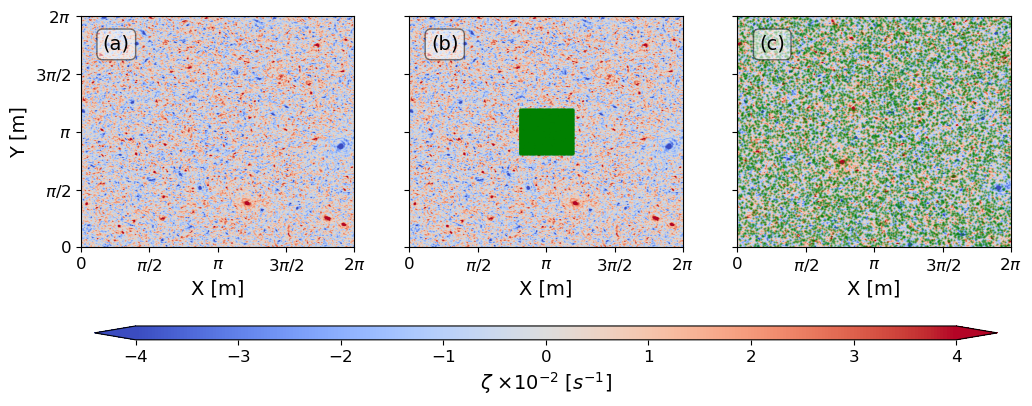

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))


im1 = ax1.pcolormesh(lonr, latr, vor[tindex,:,:], 
                    cmap='coolwarm', vmin=-4, vmax=4, shading='gouraud')
ax1.set_xlabel('X [m]', fontsize=14)
ax1.set_ylabel('Y [m]', fontsize=14)
xmin1, xmax1 = ax1.get_xlim()
ax1.set_xticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax1.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])
ax1.set_yticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax1.set_yticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])

# 
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 
# 
# cbar1 = plt.colorbar(im1, ax=ax1, pad=0.03)  # 
# cbar1.set_label('Vorticity/100', fontsize=12)
# cbar1.ax.set_title(r'[$s^{-1}$]', fontsize=14)

########################################
im1 = ax2.pcolormesh(lonr, latr, vor[tindex,:,:], 
                    cmap='coolwarm', vmin=-4, vmax=4, shading='gouraud')
ax2.scatter(lon1e4[:,0], lat1e4[:,0], s=0.5,color='g', alpha=0.4)
ax2.set_xlabel('X [m]', fontsize=14)
# ax2.set_ylabel('Y [m]', fontsize=14)
ax2.set_xticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax2.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])
ax2.set_yticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax2.set_yticklabels('')

# 
ax2.text(0.08, 0.92, '(b)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 

cax = inset_axes(ax2,
                 width="330%",  # 宽度增加到90%，更长
                 height="6%",  # 高度增加到4%
                 loc='lower center',  # 位于底部中央
                 bbox_to_anchor=(0, -0.40, 1, 1),  # 位置更低（-0.10）
                 bbox_transform=ax2.transAxes,  # 使用中间图的坐标系
                 borderpad=0)  # 无边框间距
cbar2 = plt.colorbar(im2, cax=cax, orientation='horizontal',extend='both')
cbar2.set_label(r'$\zeta$ $\times 10^{-2}$ [$s^{-1}$]', fontsize=14)
####################################
im1 = ax3.pcolormesh(lonr, latr, vor[tindex2,:,:], 
                    cmap='coolwarm', vmin=-4, vmax=4, shading='gouraud')
ax3.scatter(lon1e4[:,tindexp], lat1e4[:,tindexp], s=0.5,color='g', alpha=0.4)
# im1 = ax3.scatter(lon1e4[:,150], lat1e4[:,150], s=1.5,color='k')
ax3.set_xlabel('X [m]', fontsize=14)
ax3.set_xticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax3.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])
ax3.set_yticks([xmin1,np.pi/2,np.pi,np.pi/2*3, xmax1])
ax3.set_yticklabels('')
ax3.set_xlim([xmin1,xmax1])
ax3.set_ylim([xmin1,xmax1])

# 
ax3.text(0.08, 0.92, '(c)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))  # 

/tmp/ipykernel_1024003/671074958.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


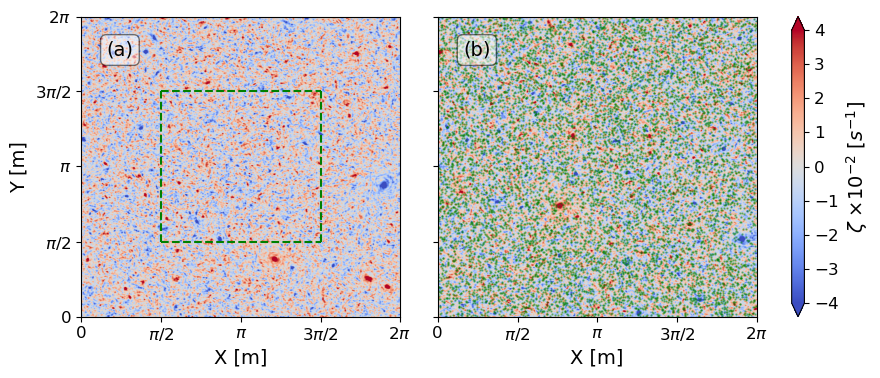

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 设置全局样式
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# 创建图形和子图 - 改为2个子图
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(8, 4))

# 第一个子图 (a)
im1 = ax1.pcolormesh(lonr, latr, vor[tindex,:,:], 
                    cmap='coolwarm', vmin=-4, vmax=4, shading='gouraud')

pio2=np.pi/2
pi3o2=np.pi*3/2
ax1.plot([pio2,pio2],[pio2,pi3o2],color='g',linestyle='--')
ax1.plot([pi3o2,pi3o2],[pio2,pi3o2],color='g',linestyle='--')
ax1.plot([pio2,pi3o2],[pio2,pio2],color='g',linestyle='--')
ax1.plot([pio2,pi3o2],[pi3o2,pi3o2],color='g',linestyle='--')

ax1.set_xlabel('X [m]', fontsize=14)
ax1.set_ylabel('Y [m]', fontsize=14)
xmin1, xmax1 = ax1.get_xlim()
ax1.set_xticks([xmin1,np.pi/2,np.pi,np.pi/2 * 3, xmax1])
ax1.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])
ax1.set_yticks([xmin1,np.pi/2,np.pi,np.pi/2 * 3, xmax1])
ax1.set_yticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])

# 添加标签
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# # 为第一个子图添加colorbar
# cbar1 = plt.colorbar(im1, ax=ax1, pad=0.03)
# cbar1.set_label(r'$\zeta$ $\times 10^{-2}$ [$s^{-1}$]', fontsize=12)

# 第三个子图 (c)
im3 = ax3.pcolormesh(lonr, latr, vor[tindex2,:,:], 
                    cmap='coolwarm', vmin=-4, vmax=4, shading='gouraud')
ax3.scatter(lon1e4[:,tindexp], lat1e4[:,tindexp], s=0.5, color='g', alpha=0.4)
ax3.set_xlabel('X [m]', fontsize=14)
ax3.set_xticks([xmin1,np.pi/2,np.pi,np.pi/2 * 3, xmax1])
ax3.set_xticklabels(['0',r'$\pi/2$',r'$\pi$',r'$3\pi/2$', r'$2\pi$'])
ax3.set_yticks([xmin1,np.pi/2,np.pi,np.pi/2 * 3, xmax1])
ax3.set_yticklabels('')
ax3.set_xlim([xmin1,xmax1])
ax3.set_ylim([xmin1,xmax1])

# 添加标签
ax3.text(0.08, 0.92, '(b)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


cax = inset_axes(ax3,
                 width="4%",  # 宽度调整为适合竖直方向
                 height="100%",  # 高度调整为适合竖直方向
                 loc='center right',  # 位于右侧中央
                 bbox_to_anchor=(0.15, 0, 1, 1),  # 调整位置，使其在右侧
                 bbox_transform=ax3.transAxes,  # 使用第二个子图的坐标系
                 borderpad=0)  # 无边框间距
cbar3 = plt.colorbar(im3, cax=cax, orientation='vertical', extend='both')
cbar3.set_label(r'$\zeta$ $\times 10^{-2}$ [$s^{-1}$]', fontsize=14)

plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig1_hit2d_vor_part_distri.png',dpi=300, bbox_inches='tight')

plt.show()